## **Revision**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image

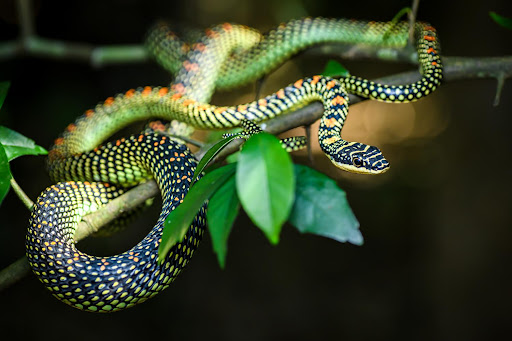

In [ ]:
Image('/content/snake.jpg')

In [ ]:
img = cv2.imread("/content/snake.jpg",0)
print(img)

[[ 8  8  8 ...  8  8  8]
 [ 8  8  8 ...  8  8  8]
 [ 8  8  8 ...  9  8  8]
 ...
 [ 6  6  6 ... 10 10 10]
 [ 6  6  6 ... 10 10 10]
 [ 7  6  6 ... 10 10 10]]


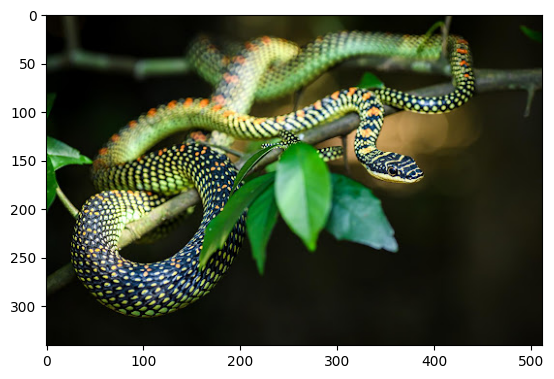

In [ ]:
img_BGR = cv2.imread('/content/snake.jpg')
img_RGB = cv2.cvtColor(img_BGR, cv2.COLOR_BGR2RGB)
plt.imshow(img_RGB)

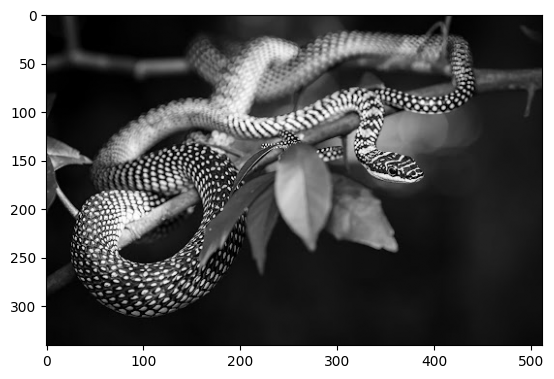

In [ ]:
img_gray = cv2.cvtColor(img_BGR, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

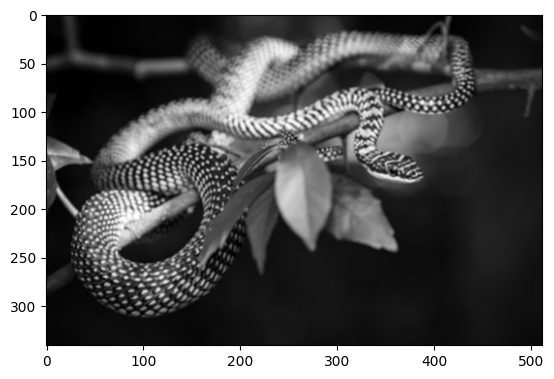

In [ ]:
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)
plt.imshow(img_blur, cmap='gray')

array([[ 8,  8,  8, ...,  9,  8,  8],
       [ 8,  8,  8, ...,  9,  8,  8],
       [ 8,  8,  8, ...,  9,  8,  8],
       ...,
       [ 6,  6,  6, ..., 10, 10, 10],
       [ 6,  6,  6, ..., 10, 10, 10],
       [ 6,  6,  6, ..., 10, 10, 10]], dtype=uint8)
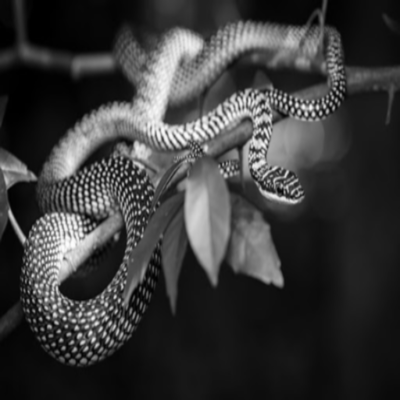

In [ ]:
# resize the image to 400x400
img_resize = cv2.resize(img_blur, (400,400))
img_resize

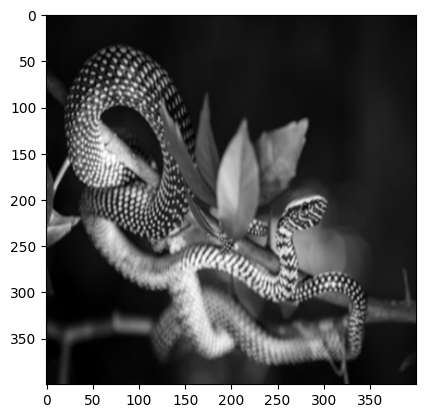

In [ ]:
# flip the image vertically
img_flip = cv2.flip(img_resize, 0)
plt.imshow(img_flip, cmap='gray')

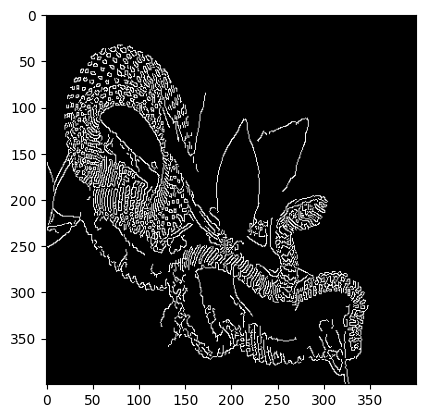

In [ ]:
# extract the edges of that image
img_edges = cv2.Canny(img_flip, 100, 200)
plt.imshow(img_edges, cmap='gray')


In [ ]:
sobelx = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1,dy=0, ksize=5) # Sobel Edge Detection on the X axis
sobely = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=0,dy=1, ksize=5) # Sobel Edge Detection on the Y axis
sobelxy = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1,dy=1, ksize=5) # Combined X and Y Sobel Edge Detection

Text(0.5, 1.0, 'Sobel XY')

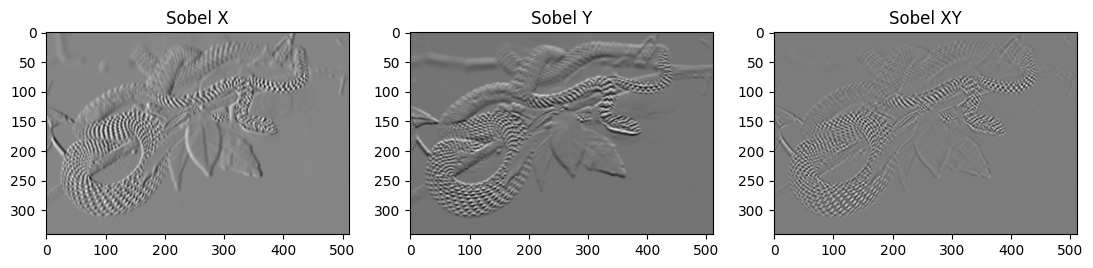

In [ ]:
# show the image
plt.figure(figsize=[18,5])
plt.subplot(141);
plt.imshow(sobelx, cmap='gray');
plt.title("Sobel X")


plt.subplot(142);
plt.imshow(sobely, cmap='gray');
plt.title("Sobel Y")


plt.subplot(143);
plt.imshow(sobelxy, cmap='gray');
plt.title("Sobel XY")

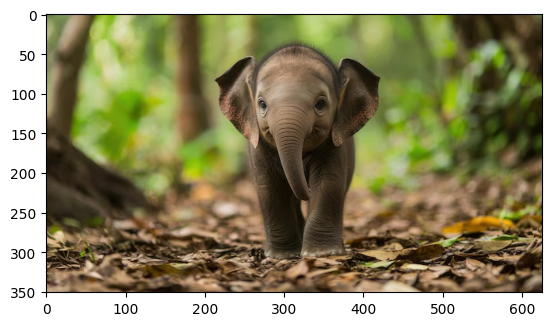

In [ ]:
img_BGR = cv2.imread('/content/elephant.avif')
img_RGB = cv2.cvtColor(img_BGR, cv2.COLOR_BGR2RGB)
plt.imshow(img_RGB)

## **Image Classification**

Image classification using CNN means teaching a deep learning model to recognize what’s inside an image (cat, dog, car, face, disease, etc.).

CNNs are especially designed for images and are far better than traditional ML for vision tasks.

### Why CNN for Images?

Images have:

Height × Width × Channels (RGB)

Spatial patterns (edges, shapes, textures)


### CNNs automatically learn:

Edges → Shapes → Objects

(no manual feature extraction needed)

 input layer >> convolutional layer >> pooling layer >> flatten layer


 output layer

 convolutional layer extract the main features

 pooling layer is used as filter

 flatten layer is used to convert in 1d

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [27]:
# load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [28]:
# checking image
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

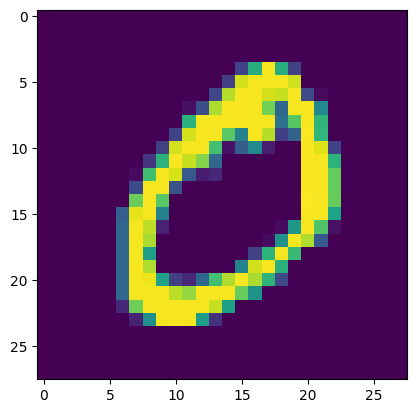

In [31]:
# checking the first image
plt.imshow(x_train[1])

In [30]:
x_train.shape

(60000, 28, 28)

In [33]:
# Normalize and scaling

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# reshape
x_train = x_train.reshape(-1, 28, 28, 1)  # (no. of imgs, size(28,28), color_channel)
x_test = x_test.reshape(-1, 28, 28, 1)

In [35]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28,1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train model
model.fit(
    x_train,y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
    )

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.4034 - loss: 1.6756 - val_accuracy: 0.9035 - val_loss: 0.3361
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.8853 - loss: 0.3681 - val_accuracy: 0.9343 - val_loss: 0.2252
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9207 - loss: 0.2629 - val_accuracy: 0.9518 - val_loss: 0.1669
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.9403 - loss: 0.1976 - val_accuracy: 0.9598 - val_loss: 0.1427
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9505 - loss: 0.1630 - val_accuracy: 0.9698 - val_loss: 0.1124


In [39]:
# evaluate  model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9609 - loss: 0.1271
Test accuracy: 0.9657999873161316


In [ ]:
# face detection



In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])